# REGRESIÓN LINEAL SIMPLE CON MINIMOS CUADRADOS ORDINARIOS PARA DATASET DE PENGUINS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
penguins_df = sns.load_dataset('penguins').dropna()
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## CORRELACIÓN DE VARIABLES

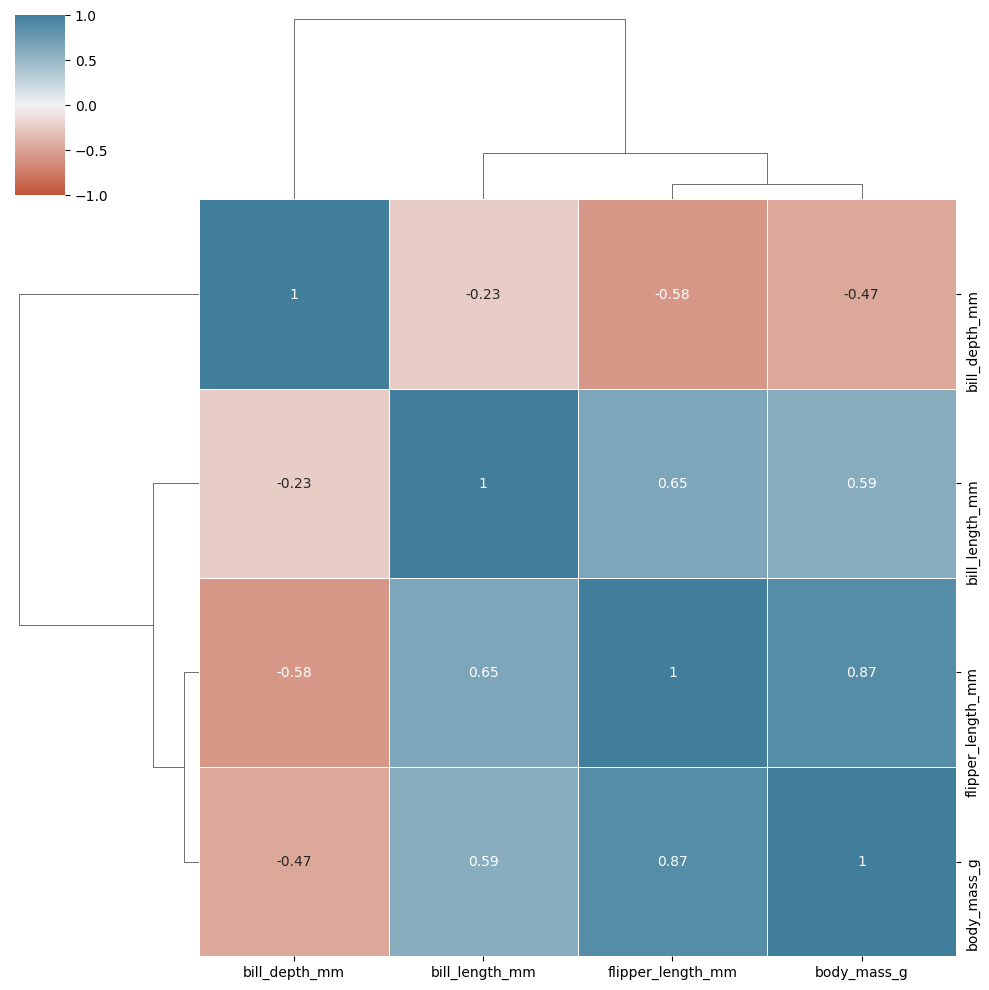

In [3]:
sns.clustermap(
    data=penguins_df.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

## REGRESIÓN LINEAL ENTRE FLIPPER_LENGTH_MM Y BODY_MASS_G

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

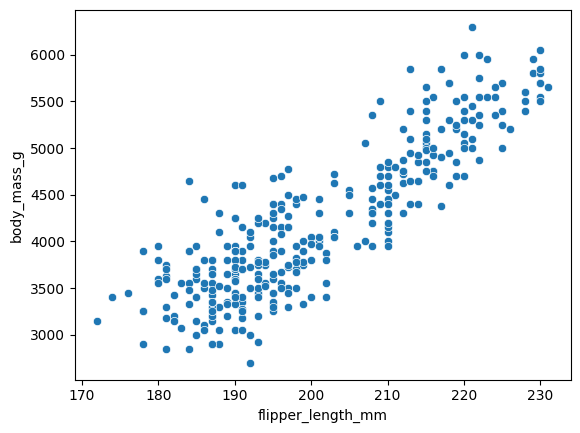

In [4]:
sns.scatterplot(
    data=penguins_df,
    x='flipper_length_mm',
    y='body_mass_g'
)

In [5]:
import scipy

In [6]:
penguins_res = scipy.stats.linregress(x=penguins_df.flipper_length_mm,y=penguins_df.body_mass_g)
penguins_res

LinregressResult(slope=np.float64(50.15326594224111), intercept=np.float64(-5872.092682842823), rvalue=np.float64(0.8729788985653613), pvalue=np.float64(3.1328362509719978e-105), stderr=np.float64(1.5402309838246344), intercept_stderr=np.float64(310.2851553513498))

## GRAFICAMOS LA REGRESIÓN LINEAL SIMPLE

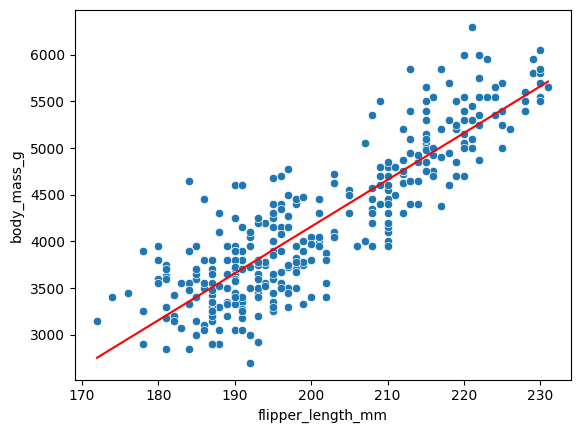

In [7]:
sns.scatterplot(
    data=penguins_df,
    x='flipper_length_mm',
    y='body_mass_g'
)

m = penguins_res.slope
b = penguins_res.intercept

fx_1 = np.array([penguins_df.flipper_length_mm.min(),penguins_df.flipper_length_mm.max()])
fy_1 = m * fx_1 + b

plt.plot(fx_1,fy_1,color='red')

## OTRA FORMA DE GRAFICAR CON SEABORN

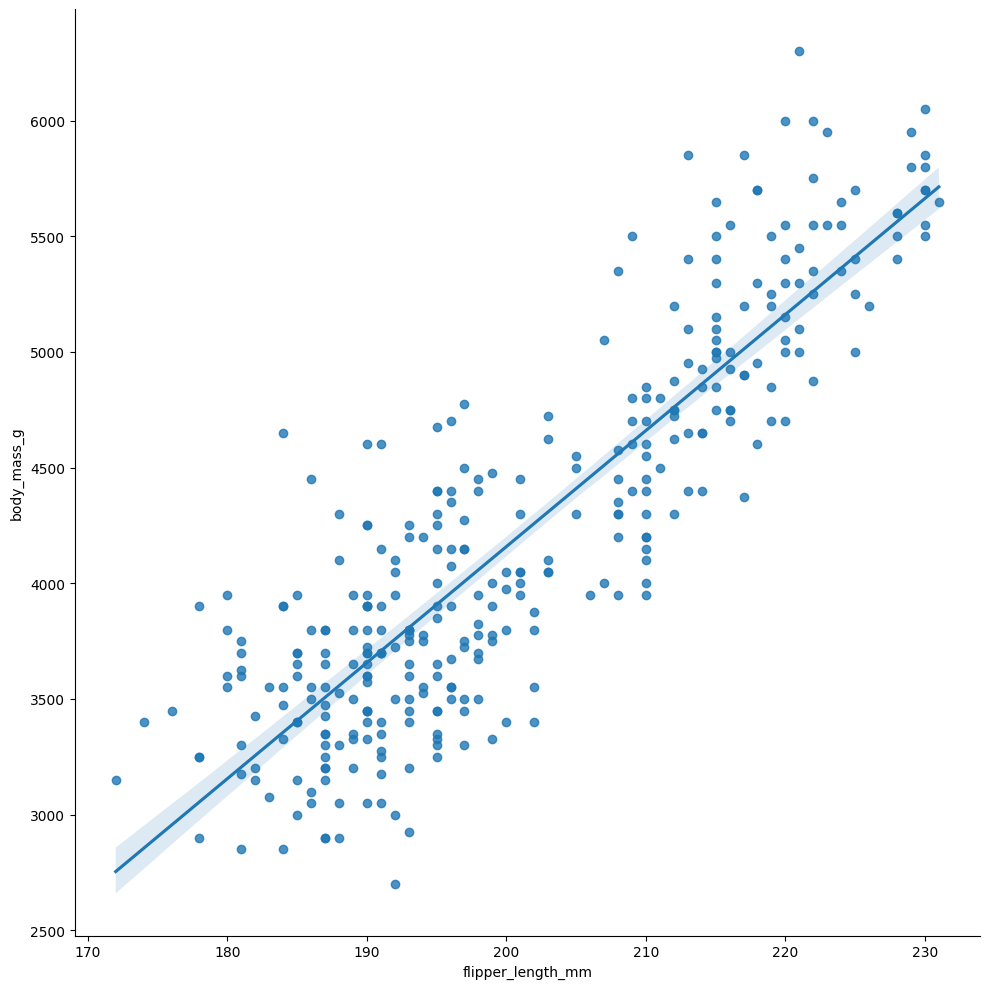

In [8]:
sns.lmplot(
    data=penguins_df,
    x='flipper_length_mm',
    y='body_mass_g',
    height=10
)

## REGRESIÓN LINEAL CON AJUSTE DE MINIMOS CUADRADOS ORDINARIOS

In [9]:
import statsmodels.formula.api as smf

In [10]:
modelo_ols = (
    smf.ols(
        formula="body_mass_g ~ flipper_length_mm",
        data=penguins_df
    )
    .fit()
)

In [11]:
data = penguins_df[['body_mass_g','flipper_length_mm']].copy()
data

,body_mass_g,flipper_length_mm
0,3750.0,181.0
1,3800.0,186.0
2,3250.0,195.0
4,3450.0,193.0
5,3650.0,190.0
...,...,...
338,4925.0,214.0
340,4850.0,215.0
341,5750.0,222.0
342,5200.0,212.0


In [12]:
data['predict'] = modelo_ols.predict(data['flipper_length_mm'])
data

,body_mass_g,flipper_length_mm,predict
0,3750.0,181.0,3205.648453
1,3800.0,186.0,3456.414782
2,3250.0,195.0,3907.794176
4,3450.0,193.0,3807.487644
5,3650.0,190.0,3657.027846
...,...,...,...
338,4925.0,214.0,4860.706229
340,4850.0,215.0,4910.859495
341,5750.0,222.0,5261.932356
342,5200.0,212.0,4760.399697


## GRAFICAMOS RESULTADOS

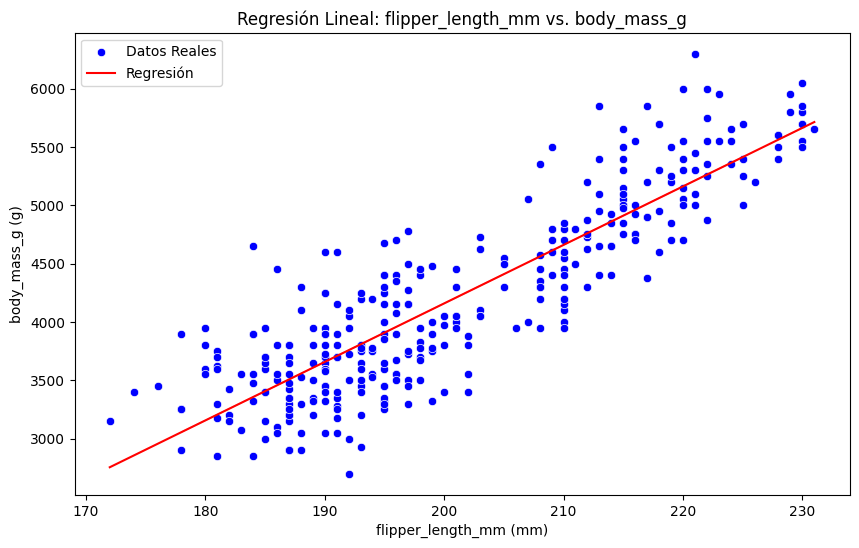

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data['flipper_length_mm'],y=data['body_mass_g'],label='Datos Reales',color='blue')
sns.lineplot(x=data['flipper_length_mm'],y=data['predict'],label='Regresión',color='red')
plt.xlabel('flipper_length_mm (mm)')
plt.ylabel('body_mass_g (g)')
plt.title('Regresión Lineal: flipper_length_mm vs. body_mass_g')
plt.legend()
plt.show()